In [1]:
pip install -U textblob

In [2]:
from google.colab import files
uploaded = files.upload()

Saving text_emotion.csv to text_emotion.csv


In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import nltk
nltk.download('wordnet')
data = pd.read_csv('text_emotion.csv')

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [4]:
data = data.drop('author', axis=1)
data

,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...
...,...,...,...
39995,1753918954,neutral,@JohnLloydTaylor
39996,1753919001,love,Happy Mothers Day All my love
39997,1753919005,love,Happy Mother's Day to all the mommies out ther...
39998,1753919043,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...


In [5]:
#Dropping rows with other emotion labels

data  = data.drop(data[data.sentiment == 'anger'].index)
data  = data.drop(data[data.sentiment == 'boredom'].index)
data  = data.drop(data[data.sentiment == 'enthusiasm'].index)
data  = data.drop(data[data.sentiment == 'empty'].index)
data  = data.drop(data[data.sentiment == 'fun'].index)
data  = data.drop(data[data.sentiment == 'relief'].index)
data  = data.drop(data[data.sentiment == 'surprise'].index)
data  = data.drop(data[data.sentiment == 'love'].index)
data  = data.drop(data[data.sentiment == 'hate'].index)
data  = data.drop(data[data.sentiment == 'neutral'].index)
data  = data.drop(data[data.sentiment == 'worry'].index)

In [6]:

%pip install -q emoji==2.10.1 contractions nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.5/421.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.5 MB/s eta 0:00:00


In [7]:
import re, nltk, emoji, contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag


for corp in ['stopwords','wordnet','omw-1.4']:
    try: nltk.data.find(f'corpora/{corp}')
    except LookupError: nltk.download(corp)


for tagger in ['averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng']:
    try: nltk.data.find(f'taggers/{tagger}')
    except LookupError:
        try: nltk.download(tagger)
        except: pass


NEGATIONS = {
    'no','nor','not',"don't","didn't","isn't","wasn't","aren't","weren't",
    "won't","can't","couldn't","shouldn't","wouldn't","doesn't","ain't","n't"
}
STOP = set(stopwords.words('english')) - NEGATIONS
WN = WordNetLemmatizer()

def _map_pos(tag):
    return {'J':'a','V':'v','N':'n','R':'r'}.get(tag[:1], 'n')

def clean_tweet(text, lemmatize=True):
    if not isinstance(text, str):
        return ''
    x = text.lower()


    x = re.sub(r'http\S+|www\.\S+', ' URL ', x)
    x = re.sub(r'@\w+', ' USER ', x)
    x = re.sub(r'\brt\b', ' ', x)
    x = re.sub(r'#(\w+)', r'\1', x)


    x = emoji.demojize(x)
    x = contractions.fix(x)
    x = re.sub(r'(.)\1{2,}', r'\1\1', x)
    x = re.sub(r'\d+', ' NUM ', x)

    x = re.sub(r'[^\w\s]', ' ', x)
    x = re.sub(r'\s+', ' ', x).strip()


    if lemmatize and x:
        toks = x.split()
        tags = pos_tag(toks)
        x = ' '.join(WN.lemmatize(w, _map_pos(t)) for w, t in tags)


    toks = [w for w in x.split() if w not in STOP]
    return ' '.join(toks)


data['content_clean'] = data['content'].apply(clean_tweet)

print(data[['content','content_clean']].head(3))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


                                             content  \
1  Layin n bed with a headache  ughhhh...waitin o...   
2                Funeral ceremony...gloomy friday...   
6  I should be sleep, but im not! thinking about ...   

                                       content_clean  
1              layin n bed headache ughh waitin call  
2                     funeral ceremony gloomy friday  
6  sleep not think old friend want marry damn amp...  


In [8]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
data['content'] = data['content'].str.lower()


data['content'] = data['content'].str.replace(r'[^\w\s]', ' ', regex=True)


stop = set(stopwords.words('english'))
data['content'] = data['content'].apply(lambda x: " ".join(word for word in x.split() if word not in stop))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
# top 10,000 rarest words
# appearing in the data
freq = pd.Series(' '.join(data['content']).split()).value_counts()[-10000:]

# Removing all those rarely appearing words from the data
freq = list(freq.index)
data['content'] = data['content'].apply(lambda x: " ".join(x for x in x.split() if x not in freq))

In [10]:
from sklearn import preprocessing
lbl_enc = preprocessing.LabelEncoder()
y = lbl_enc.fit_transform(data.sentiment.values)


from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(data.content.values, y, stratify=y, random_state=42, test_size=0.25, shuffle=True)
X_train

array(['totally ignoring sad heartbroken', 'sick fighting looks like',
       'either fucked mind pretty sure internet', ...,
       'haha austin bad call',
       'hannah_21thanks keep working roshikk lol good idea',
       'wishes pool'], dtype=object)

In [32]:
# Extracting TF-IDF parameters
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=1000, analyzer='word',ngram_range=(1,3))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

In [33]:
# Extracting Count Vectors Parameters
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer(analyzer='word')
count_vect.fit(data['content'])
X_train_count =  count_vect.transform(X_train)
X_val_count =  count_vect.transform(X_val)

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_val, y_val):
    y_pred = model.predict(X_val)
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec  = recall_score(y_val, y_pred, average='macro')
    f1   = f1_score(y_val, y_pred, average='macro')
    print(f"{model.__class__.__name__} -> Acc: {acc:.3f}, Prec: {prec:.3f}, Rec: {rec:.3f}, F1: {f1:.3f}")
    return acc

# Models using the TF-IDF features

## Model 1: Multinomial Naive Bayes Classifier

In [35]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import MultinomialNB
accuracy=[]
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred = nb.predict(X_val_tfidf)
accuracy.append(accuracy_score(y_pred, y_val)*100)
print('naive bayes tfidf accuracy %s' % accuracy_score(y_pred, y_val))
confusion_matrix(y_val, y_pred)

naive bayes tfidf accuracy 0.8138862102217936


array([[428,  93],
       [100, 416]])

## Model 2: Linear SVM

In [36]:
from sklearn.linear_model import SGDClassifier
lsvm = SGDClassifier(alpha=0.001, random_state=5, max_iter=15, tol=None)
lsvm.fit(X_train_tfidf, y_train)
y_pred = lsvm.predict(X_val_tfidf)
accuracy.append(accuracy_score(y_pred, y_val)*100)
print('svm using tfidf accuracy %s' %accuracy_score(y_pred, y_val))
confusion_matrix(y_val, y_pred)

svm using tfidf accuracy 0.8167791706846673


array([[448,  73],
       [117, 399]])

## Model 3: logistic regression

In [37]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(C=1)
logreg.fit(X_train_tfidf, y_train)
y_pred = logreg.predict(X_val_tfidf)
accuracy.append(accuracy_score(y_pred, y_val)*100)
print('log reg tfidf accuracy %s' % accuracy_score(y_pred, y_val))
confusion_matrix(y_val, y_pred)

log reg tfidf accuracy 0.8244937319189971


array([[444,  77],
       [105, 411]])

## Model 4: Random Forest Classifier

In [38]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500)
rf.fit(X_train_tfidf, y_train)
y_pred = rf.predict(X_val_tfidf)
accuracy.append(accuracy_score(y_pred, y_val)*100)
print('randon forest tfidf accuracy %s' % accuracy_score(y_pred, y_val))
confusion_matrix(y_val, y_pred)

randon forest tfidf accuracy 0.81099324975892


array([[445,  76],
       [120, 396]])

# Models using count vectors features

## Model 1: Multinomial Naive Bayes Classifier

In [39]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train_count, y_train)
y_pred = nb.predict(X_val_count)
accuracy.append(accuracy_score(y_pred, y_val)*100)
print('naive bayes count vectors accuracy %s' % accuracy_score(y_pred, y_val))
confusion_matrix(y_val, y_pred)

naive bayes count vectors accuracy 0.7839922854387656


array([[404, 117],
       [107, 409]])

## Model 2: Linear SVM

In [40]:
from sklearn.linear_model import SGDClassifier
lsvm = SGDClassifier(alpha=0.001, random_state=5, max_iter=15, tol=None)
lsvm.fit(X_train_count, y_train)
y_pred = lsvm.predict(X_val_count)
accuracy.append(accuracy_score(y_pred, y_val)*100)
print('lsvm using count vectors accuracy %s' % accuracy_score(y_pred, y_val))
confusion_matrix(y_val, y_pred)

lsvm using count vectors accuracy 0.8100289296046287


array([[426,  95],
       [102, 414]])

## Model 3: Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(C=1)
logreg.fit(X_train_count, y_train)
y_pred = logreg.predict(X_val_count)
accuracy.append(accuracy_score(y_pred, y_val)*100)
print('log reg count vectors accuracy %s' % accuracy_score(y_pred, y_val))
confusion_matrix(y_val, y_pred)

log reg count vectors accuracy 0.8129218900675024


array([[424,  97],
       [ 97, 419]])

## Model 4: Random Forest Classifier

In [42]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500)
rf.fit(X_train_count, y_train)
y_pred = rf.predict(X_val_count)
accuracy.append(accuracy_score(y_pred, y_val)*100)
print('random forest with count vectors accuracy %s' % accuracy_score(y_pred, y_val))
confusion_matrix(y_val, y_pred)

random forest with count vectors accuracy 0.8032786885245902


array([[430,  91],
       [113, 403]])

# Graph based analysis

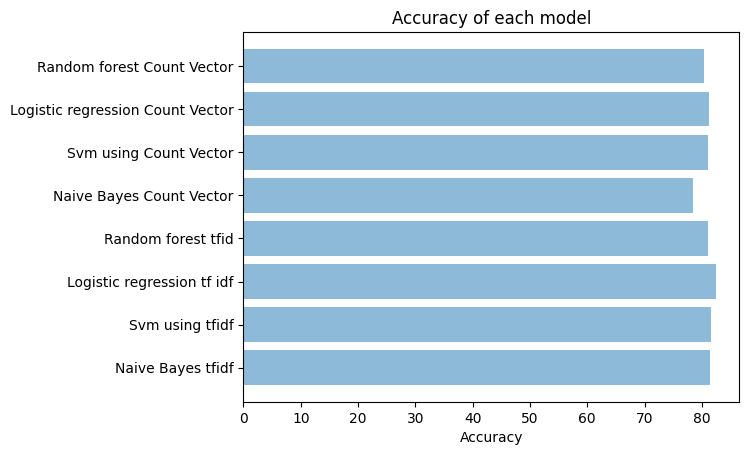

In [43]:
objects = ('Naive Bayes tfidf', 'Svm using tfidf',
           'Logistic regression tf idf', 'Random forest tfid',
           'Naive Bayes Count Vector', 'Svm using Count Vector',
           'Logistic regression Count Vector', 'Random forest Count Vector')
y_pos = np.arange(len (objects))
plt.barh(y_pos, accuracy, align='center', alpha=0.5)
plt.yticks (y_pos, objects)
plt.xlabel('Accuracy')
plt.title('Accuracy of each model')

plt.show()

#metric eval

In [44]:
# Train all 8 models (TF-IDF + Count Vector versions)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# TF-IDF Models
nb_tfidf     = MultinomialNB().fit(X_train_tfidf, y_train)
lsvm_tfidf   = SGDClassifier(alpha=0.001, random_state=5, max_iter=15, tol=None).fit(X_train_tfidf, y_train)
logreg_tfidf = LogisticRegression(C=1, max_iter=1000).fit(X_train_tfidf, y_train)
rf_tfidf     = RandomForestClassifier(n_estimators=500, random_state=5).fit(X_train_tfidf, y_train)

# Count Vector Models
nb_count     = MultinomialNB().fit(X_train_count, y_train)
lsvm_count   = SGDClassifier(alpha=0.001, random_state=5, max_iter=15, tol=None).fit(X_train_count, y_train)
logreg_count = LogisticRegression(C=1, max_iter=1000).fit(X_train_count, y_train)
rf_count     = RandomForestClassifier(n_estimators=500, random_state=5).fit(X_train_count, y_train)

# Evaluation helper
def evaluate_model(name, model, X_val, y_val, metrics_table):
    y_pred = model.predict(X_val)
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average="macro")
    rec  = recall_score(y_val, y_pred, average="macro")
    f1   = f1_score(y_val, y_pred, average="macro")
    metrics_table.append([name, acc, prec, rec, f1])

metrics_table = []

# Evaluate all models
evaluate_model("Naive Bayes TF-IDF", nb_tfidf, X_val_tfidf, y_val, metrics_table)
evaluate_model("SVM TF-IDF", lsvm_tfidf, X_val_tfidf, y_val, metrics_table)
evaluate_model("Logistic Regression TF-IDF", logreg_tfidf, X_val_tfidf, y_val, metrics_table)
evaluate_model("Random Forest TF-IDF", rf_tfidf, X_val_tfidf, y_val, metrics_table)

evaluate_model("Naive Bayes Count Vector", nb_count, X_val_count, y_val, metrics_table)
evaluate_model("SVM Count Vector", lsvm_count, X_val_count, y_val, metrics_table)
evaluate_model("Logistic Regression Count Vector", logreg_count, X_val_count, y_val, metrics_table)
evaluate_model("Random Forest Count Vector", rf_count, X_val_count, y_val, metrics_table)


# Display neatly
df_metrics = pd.DataFrame(metrics_table,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
df_metrics = df_metrics.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print(df_metrics.to_string(index=False, float_format="%.3f"))

                           Model  Accuracy  Precision  Recall  F1-Score
      Logistic Regression TF-IDF     0.824      0.825   0.824     0.824
            Random Forest TF-IDF     0.818      0.820   0.818     0.817
                      SVM TF-IDF     0.817      0.819   0.817     0.816
              Naive Bayes TF-IDF     0.814      0.814   0.814     0.814
Logistic Regression Count Vector     0.813      0.813   0.813     0.813
                SVM Count Vector     0.810      0.810   0.810     0.810
      Random Forest Count Vector     0.797      0.797   0.796     0.796
        Naive Bayes Count Vector     0.784      0.784   0.784     0.784


In [45]:
from sklearn.ensemble import VotingClassifier
ensemble_top4 = VotingClassifier(
    estimators=[
        ('nb', nb_count),
        ('svm', lsvm_count),
        ('lr', logreg_count),
        ('rf', rf_count)
    ],
    voting='hard'      # all models support this
)
ensemble_top4.fit(X_train_count, y_train)
evaluate_model("Ensemble (Top-4 Count Vector)", ensemble_top4, X_val_count, y_val, metrics_table)

In [46]:
import pandas as pd

df_metrics = pd.DataFrame(metrics_table,
    columns=["Model","Accuracy","Precision","Recall","F1-Score"]
).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print(df_metrics.to_string(index=False, float_format="%.3f"))

                           Model  Accuracy  Precision  Recall  F1-Score
      Logistic Regression TF-IDF     0.824      0.825   0.824     0.824
            Random Forest TF-IDF     0.818      0.820   0.818     0.817
                      SVM TF-IDF     0.817      0.819   0.817     0.816
              Naive Bayes TF-IDF     0.814      0.814   0.814     0.814
Logistic Regression Count Vector     0.813      0.813   0.813     0.813
   Ensemble (Top-4 Count Vector)     0.813      0.814   0.813     0.813
                SVM Count Vector     0.810      0.810   0.810     0.810
      Random Forest Count Vector     0.797      0.797   0.796     0.796
        Naive Bayes Count Vector     0.784      0.784   0.784     0.784


In [47]:
from sklearn.metrics import confusion_matrix, classification_report
yp = ensemble_top4.predict(X_val_count)
print("Confusion matrix:\n", confusion_matrix(y_val, yp))
print("\nReport:\n", classification_report(y_val, yp, target_names=list(lbl_enc.classes_)))

Confusion matrix:
 [[438  83]
 [111 405]]

Report:
               precision    recall  f1-score   support

   happiness       0.80      0.84      0.82       521
     sadness       0.83      0.78      0.81       516

    accuracy                           0.81      1037
   macro avg       0.81      0.81      0.81      1037
weighted avg       0.81      0.81      0.81      1037



In [48]:
import joblib
joblib.dump({
    "vectorizer": count_vect,
    "label_encoder": lbl_enc,
    "model": ensemble_top4
}, "spotify_sentiment_ensemble.joblib")
print("Saved -> spotify_sentiment_ensemble.joblib")

Saved -> spotify_sentiment_ensemble.joblib


# REALITY CHECK

In [49]:
tweets = pd.DataFrame(['I am very happy today! The atmosphere looks cheerful',
'Things are looking great. It was such a good day',
'Success is right around the corner. Lets celebrate this victory',
'Everything is more beautiful when you experience them with a smile!',
'Now this is my worst, okay? But I am gonna get better.',
'I am tired, boss. Tired of being on the road, lonely as a sparrow in the rain. I am tired of all the pain I feel',
'This is quite depressing. I am filled with sorrow',
'His death broke my heart. It was a sad day'])

# preprocessing on these tweets as done before
tweets[0] = tweets[0].str.replace('[^\w\s]',' ')
from nltk.corpus import stopwords
stop = stopwords.words('english')
tweets[0] = tweets[0].apply(lambda x: " ".join(x for x in x.split() if x not in stop))
from textblob import Word
tweets[0] = tweets[0].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))

# Extracting Count Vectors feature from our tweets
tweet_count = count_vect.transform(tweets[0])

#Predicting the emotion of the tweet using our already trained linear SVM
tweet_pred = lsvm.predict(tweet_count)

print(tweet_pred)

[0 0 0 0 1 1 1 1]


<>:11: SyntaxWarning: invalid escape sequence '\w'
<>:11: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipython-input-3104624424.py:11: SyntaxWarning: invalid escape sequence '\w'
  tweets[0] = tweets[0].str.replace('[^\w\s]',' ')


In [50]:
tweets = pd.DataFrame({
    'text': [
        'I am very happy today! The atmosphere looks cheerful',
        'This is quite depressing. I am filled with sorrow'
    ]
})

# clean with the SAME function
tweets['clean'] = tweets['text'].apply(clean_tweet)

# transform with the SAME vectorizer used to train the model
X_tweets = tfidf.transform(tweets['clean'])

# use the model that was trained on TF-IDF
best_model = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', solver='liblinear')
best_model.fit(X_train_tfidf, y_train)
pred = best_model.predict(X_tweets)
tweets['predicted_sentiment'] = lbl_enc.inverse_transform(pred)
print(tweets[['text','predicted_sentiment']])


                                                text predicted_sentiment
0  I am very happy today! The atmosphere looks ch...           happiness
1  This is quite depressing. I am filled with sorrow           happiness


In [51]:
# FINALIZE: train/val/test + metrics + interpretability + save
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import numpy as np, joblib

# Data (clean text + encoded labels)
X_all = data['content_clean'].values
y_all = lbl_enc.transform(data['sentiment'].values)

# 80/10/10 split: train/val/test (stratified, reproducible)
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.20, stratify=y_all, random_state=42 )
X_val, X_test, y_val, y_test = train_test_split( X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42 )

# Pipeline + small grid (fast, strong baseline)
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear", random_state=42)),
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [2, 5],
    "tfidf__max_df": [0.95, 0.98],
    "clf__C": [0.5, 1.0, 2.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(pipe, param_grid, scoring="f1_macro", cv=cv, n_jobs=-1)
gs.fit(X_train, y_train)

# Validation quick check
val_pred = gs.predict(X_val)
print("Val macro-F1:", f1_score(y_val, val_pred, average="macro"))

# Final TEST report
y_pred = gs.predict(X_test)
print("\n=== TEST REPORT ===")
print(classification_report(y_test, y_pred, target_names=lbl_enc.classes_))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
if len(lbl_enc.classes_) == 2:
    y_proba = gs.predict_proba(X_test)[:, 1]
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# Top features (LogReg)
tfidf = gs.best_estimator_["tfidf"]
clf   = gs.best_estimator_["clf"]
feat  = tfidf.get_feature_names_out()
coef  = clf.coef_[0]
top_pos = np.argsort(coef)[-15:][::-1]
top_neg = np.argsort(coef)[:15]
print("\nTop features for class:", lbl_enc.classes_[np.argmax(clf.classes_)], feat[top_pos])
print("Top features for class:", lbl_enc.classes_[np.argmin(clf.classes_)], feat[top_neg])

# ---- Save best model ----
joblib.dump(gs.best_estimator_, "twitter_sentiment_pipeline.joblib")
print("\nSaved model -> twitter_sentiment_pipeline.joblib")

Val macro-F1: 0.8311811782479309

=== TEST REPORT ===
              precision    recall  f1-score   support

   happiness       0.79      0.83      0.81       521
     sadness       0.82      0.78      0.80       517

    accuracy                           0.81      1038
   macro avg       0.81      0.81      0.81      1038
weighted avg       0.81      0.81      0.81      1038

Confusion matrix:
 [[435  86]
 [115 402]]
ROC-AUC: 0.889275199827738

Top features for class: sadness ['sad' 'miss' 'not' 'suck' 'bad' 'no' 'sorry' 'hate' 'hurt' 'cry' 'sick'
 'cannot' 'bore' 'wish' 'lose']
Top features for class: happiness ['great' 'thanks' 'happy' 'good' 'awesome' 'haha' 'cannot wait' 'yay'
 'fun' 'lol' 'enjoy' 'excite' 'thank' 'nice' 'glad']

Saved model -> twitter_sentiment_pipeline.joblib


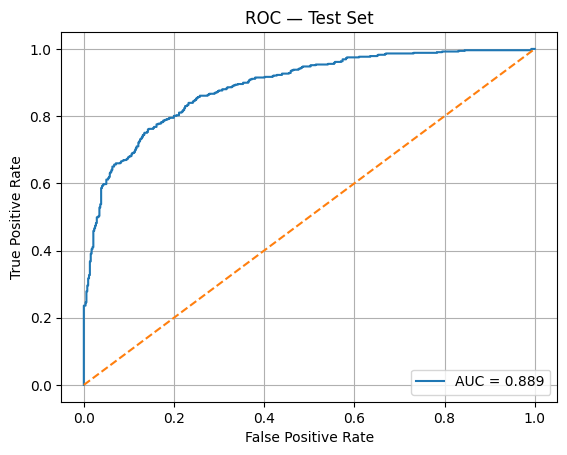

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

def _score_vector(model, X):
    if hasattr(model, "predict_proba"):
        S = model.predict_proba(X)
        return S
    if hasattr(model, "decision_function"):
        S = model.decision_function(X)
        # convert to (n_samples, 2) like proba for uniform handling
        if S.ndim == 1:
            S = np.c_[1 - (S - S.min()) / (S.max() - S.min() + 1e-12),
                      (S - S.min()) / (S.max() - S.min() + 1e-12)]
        return S
    P = model.predict(X)
    # make a 2-col "score" guess
    return np.c_[1 - P, P]

def plot_roc(model, X, y, lbl_enc=None, positive_class_name=None, title="ROC Curve"):
    classes = np.unique(y)
    is_binary = len(classes) == 2
    S = _score_vector(model, X)

    plt.figure()
    if is_binary:
        # pick positive label
        if positive_class_name is not None and lbl_enc is not None:
            pos_label = lbl_enc.transform([positive_class_name])[0]
        else:
            pos_label = 1
        if S.ndim == 1:
            pos_scores = S
        else:
            if hasattr(model, "classes_"):
                clf = model
                if hasattr(model, "named_steps") and "clf" in model.named_steps:
                    clf = model.named_steps["clf"]
                if hasattr(clf, "classes_"):
                    class_order = clf.classes_
                    # find column idx of pos_label
                    try:
                        col = list(class_order).index(pos_label)
                    except ValueError:
                        col = 1  # fallback
                    pos_scores = S[:, col]
                else:
                    pos_scores = S[:, 1] if S.shape[1] > 1 else S.ravel()
            else:
                pos_scores = S[:, 1] if S.shape[1] > 1 else S.ravel()

        fpr, tpr, _ = roc_curve(y, pos_scores, pos_label=pos_label)
        auc_val = roc_auc_score(y, pos_scores)
        plt.plot(fpr, tpr, label=f"AUC = {auc_val:.3f}")
    else:
        Y = label_binarize(y, classes=classes)
        if S.ndim == 1:
            S = np.c_[1 - S, S]
        fpr, tpr, _ = roc_curve(Y.ravel(), S.ravel())
        auc_val = roc_auc_score(Y, S, average="micro", multi_class="ovr")
        plt.plot(fpr, tpr, label=f"micro-avg AUC = {auc_val:.3f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# If you used GridSearchCV:
model = gs.best_estimator_
X_eval = X_test
y_eval = y_test
plot_roc(model, X_eval, y_eval, lbl_enc=lbl_enc, title="ROC — Test Set")

In [53]:
import re
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support
)

# -----------------------------
# 1) Prepare data
# -----------------------------
# Use your cleaned text column (already created in your notebook)
X = data["content_clean"].fillna("").values
y = lbl_enc.transform(data["sentiment"].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------------
# 2) Build pipeline
# -----------------------------
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(sublinear_tf=True)),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [2, 5],
    "tfidf__max_df": [0.95, 0.99],
    "clf__C": [0.5, 1.0, 2.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV macro-F1:", round(grid.best_score_, 4))

# -----------------------------
# 3) Test evaluation
# -----------------------------
y_pred = grid.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")

print("\n=== TEST METRICS ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Macro:  {f1:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=lbl_enc.classes_))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# -----------------------------
# 4) Save artifacts
# -----------------------------
joblib.dump({
    "model_pipeline": grid.best_estimator_,
    "label_encoder": lbl_enc
}, "twitter_sentiment_model_artifacts.joblib")

print("\nSaved -> twitter_sentiment_model_artifacts.joblib")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'clf__C': 1.0, 'tfidf__max_df': 0.95, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV macro-F1: 0.8145

=== TEST METRICS ===
Accuracy:  0.8188
Precision: 0.8194
Recall:    0.8187
F1-Macro:  0.8187

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   happiness       0.81      0.84      0.82      1042
     sadness       0.83      0.80      0.81      1033

    accuracy                           0.82      2075
   macro avg       0.82      0.82      0.82      2075
weighted avg       0.82      0.82      0.82      2075


Confusion Matrix:
 [[876 166]
 [210 823]]

Saved -> twitter_sentiment_model_artifacts.joblib


In [54]:
def predict_sentiment(texts, artifacts_path="twitter_sentiment_model_artifacts.joblib"):
    bundle = joblib.load(artifacts_path)
    model = bundle["model_pipeline"]
    le = bundle["label_encoder"]

    if isinstance(texts, str):
        texts = [texts]

    cleaned = [clean_tweet(t) for t in texts]
    pred_ids = model.predict(cleaned)
    pred_labels = le.inverse_transform(pred_ids)

    # probabilities if supported
    probs = None
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(cleaned)

    results = []
    for i, t in enumerate(texts):
        row = {
            "text": t,
            "cleaned_text": cleaned[i],
            "predicted_sentiment": pred_labels[i]
        }
        if probs is not None:
            row["confidence"] = float(np.max(probs[i]))
        results.append(row)
    return pd.DataFrame(results)

# Example
demo = predict_sentiment([
    "I feel amazing today, everything is going great!",
    "This is so disappointing and sad."
])
print(demo)

                                               text  \
0  I feel amazing today, everything is going great!   
1                 This is so disappointing and sad.   

                           cleaned_text predicted_sentiment  confidence  
0  feel amaze today everything go great           happiness    0.800692  
1                     disappointing sad             sadness    0.966693  


In [55]:
def show_top_features(trained_pipeline, label_encoder, top_n=15):
    tfidf = trained_pipeline.named_steps["tfidf"]
    clf = trained_pipeline.named_steps["clf"]

    feature_names = tfidf.get_feature_names_out()

    # Binary case
    if len(clf.coef_) == 1:
        coefs = clf.coef_[0]
        top_pos_idx = np.argsort(coefs)[-top_n:][::-1]
        top_neg_idx = np.argsort(coefs)[:top_n]

        # In binary sklearn logistic regression, coef_ corresponds to clf.classes_[1]
        class_1 = label_encoder.inverse_transform([clf.classes_[1]])[0]
        class_0 = label_encoder.inverse_transform([clf.classes_[0]])[0]

        print(f"\nTop features for class '{class_1}':")
        print(feature_names[top_pos_idx])

        print(f"\nTop features for class '{class_0}':")
        print(feature_names[top_neg_idx])

    else:
        # Multi-class case
        for class_idx, class_id in enumerate(clf.classes_):
            label = label_encoder.inverse_transform([class_id])[0]
            class_coefs = clf.coef_[class_idx]
            top_idx = np.argsort(class_coefs)[-top_n:][::-1]

            print(f"\nTop features for class '{label}':")
            print(feature_names[top_idx])

# Example usage after training:
show_top_features(grid.best_estimator_, lbl_enc, top_n=12)


Top features for class 'sadness':
['sad' 'miss' 'not' 'suck' 'bad' 'no' 'sorry' 'hate' 'hurt' 'cry' 'sick'
 'cannot']

Top features for class 'happiness':
['great' 'thanks' 'happy' 'good' 'awesome' 'haha' 'cannot wait' 'yay'
 'fun' 'lol' 'enjoy' 'excite']


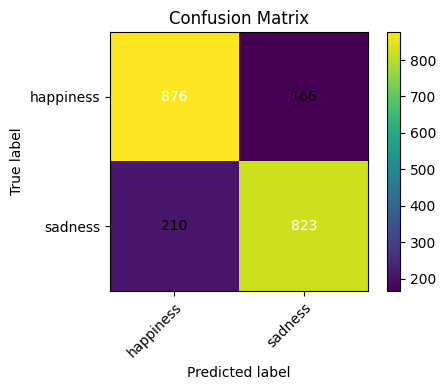

In [56]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest")
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="True label",
        xlabel="Predicted label",
        title="Confusion Matrix"
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()

# Example:
plot_confusion_matrix(y_test, y_pred, lbl_enc.classes_)